In [1]:
import gzip
import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm
import utilities as util
import glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import h5netcdf
import contextily as cx
import hvplot.xarray
import zipfile
import importlib
import download as dwld

importlib.reload(dwld)

data_dir = pathlib.Path().cwd().parent / 'data'
# swot_path = data_dir / 'usgs_swot_data' / 'swot_timeseries_for_usgs_nodes.csv'
# mrms_path_flag = data_dir / 'usgs_mrms_data' 
# usgs_path = data_dir / 'usgs_stage_data'
start_time = '2023-06-01T00:00:00Z'
end_time = '2024-02-01T00:00:00Z'
# precip_dir =  data_dir / 'pass_level_work/MRMS_precip'
# os.makedirs(precip_dir, exist_ok=True)
# precip_path = data_dir / 'pass_level_work/MRMS_precip/pass_{pass_no}_MRMS_{var_name}.csv'

In [2]:
earthaccess.login()

In [47]:
slc_results = earthaccess.search_data(short_name = 'SWOT_L1B_HR_SLC_D', 
                                        #temporal = ('2024-01-01 00:00:00', '2024-01-30 23:59:59'), # can also specify by time
                                        bounding_box = (-100.67, 31.964, -100.665, 31.965)#,
                                        # granule_name=f'*SLC*_*_{p}_228R*'
                                        # count=5
                                        ) # Lake Travis near Austin, TX

RuntimeError: {"errors":["An Internal Error has occurred."]}

In [8]:
slc_results

[Collection: {'Version': 'D', 'ShortName': 'SWOT_L1B_HR_SLC_D'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -100.74451294154514, 'SouthBoundingCoordinate': 31.234116555141757, 'EastBoundingCoordinate': -99.91364688164434, 'NorthBoundingCoordinate': 31.973762867720378}]}, 'Track': {'Cycle': 453, 'Passes': [{'Pass': 11, 'Tiles': ['210R']}]}}}
 Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2023-03-08T10:24:39.555Z', 'BeginningDateTime': '2023-03-08T10:24:27.764Z'}}
 Size(MB): 1993.1866207122803
 Data: ['https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L1B_HR_SLC_D/SWOT_L1B_HR_SLC_453_011_210R_20230308T102428_20230308T102439_PGD0_01.nc'],
 Collection: {'Version': 'D', 'ShortName': 'SWOT_L1B_HR_SLC_D'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -101.45760535493957, 'SouthBoundingCoordinate': 31.356842285712442,

In [41]:
p=50
pixc_results = earthaccess.search_data(
    short_name='SWOT_L2_HR_PIXC_2.0',
    temporal=('2023-02-01 00:00:00', '2026-03-15 23:59:59'),
    granule_name=f'*PIXC*_*_{p}_*',
    # bounding_box=(-125, 24, -66.5, 45)  # CONUS
    bounding_box = (-100.725, 31.93, -100.723, 31.94)
)

RuntimeError: {"errors":["An Internal Error has occurred."]}

In [15]:
download_index = 10
test_download = pixc_results[download_index]
output_dir = './data_downloads/pixc_downloads'
os.makedirs(output_dir, exist_ok=True)
test =earthaccess.download(test_download, output_dir)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
test[0]

PosixPath('data_downloads/pixc_downloads/SWOT_L2_HR_PIXC_487_011_210R_20230411T050555_20230411T050606_PGC0_01.nc')

In [29]:
test_file = xr.open_dataset(test[0], group='pixel_cloud')

In [33]:
test_file

<xarray.Dataset> Size: 1GB
Dimensions:                                (points: 5047800, complex_depth: 2,
                                            num_pixc_lines: 3251)
Coordinates:
    latitude                               (points) float64 40MB ...
    longitude                              (points) float64 40MB ...
Dimensions without coordinates: points, complex_depth, num_pixc_lines
Data variables: (12/61)
    azimuth_index                          (points) float64 40MB ...
    range_index                            (points) float64 40MB ...
    interferogram                          (points, complex_depth) float32 40MB ...
    power_plus_y                           (points) float32 20MB ...
    power_minus_y                          (points) float32 20MB ...
    coherent_power                         (points) float32 20MB ...
    ...                                     ...
    pixc_line_qual                         (num_pixc_lines) float64 26kB ...
    pixc_line_to_tvp                       (num_pixc_lines) float32 13kB ...
    data_window_first_valid                (num_pixc_lines) float64 26kB ...
    data_window_last_valid                 (num_pixc_lines) float64 26kB ...
    data_window_first_cross_track          (num_pixc_lines) float32 13kB ...
    data_window_last_cross_track           (num_pixc_lines) float32 13kB ...
Attributes:
    description:                 cloud of geolocated interferogram pixels
    interferogram_size_azimuth:  3251
    interferogram_size_range:    4724
    looks_to_efflooks:           1.5375021468786667
    num_azimuth_looks:           7.0
    azimuth_offset:              8

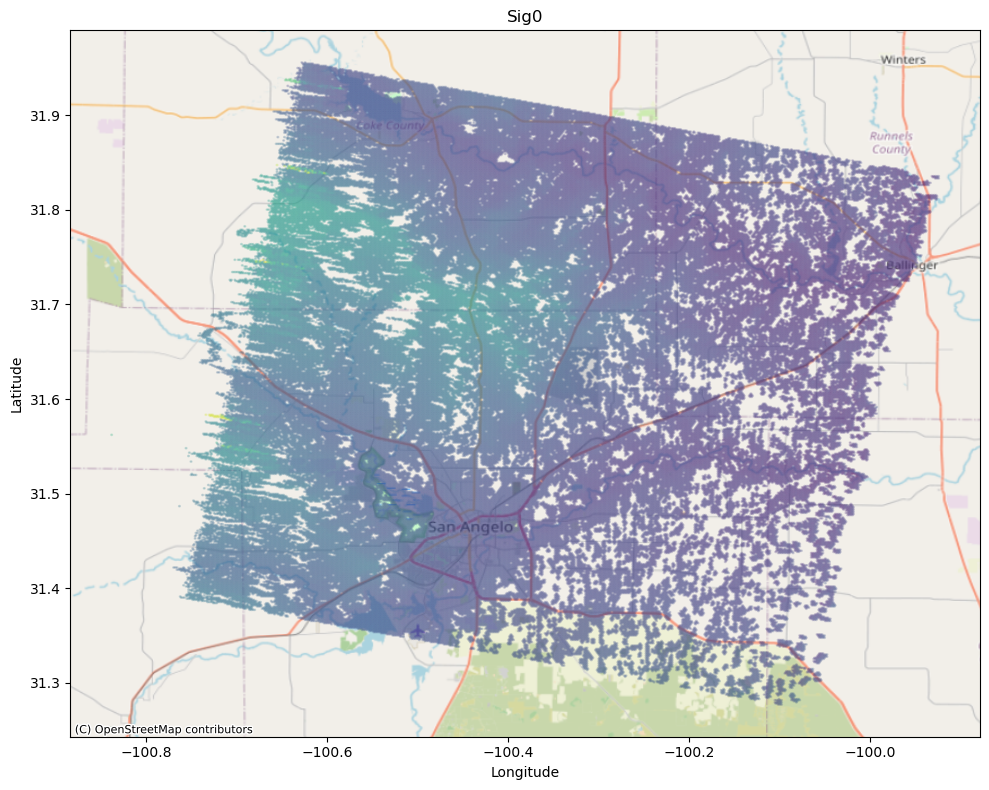

In [38]:

import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(figsize=(10, 8))
# test_file.scatter(x='longitude', y='latitude', ax=ax, c='sig0', cmap='viridis', s=10, alpha=0.7)
# scatter1 = ax.scatter(x=test_file.longitude, y=test_file.latitude, c=test_file.height, cmap='Reds', vmin=2930, vmax=2970, alpha=1)
hb = ax.hexbin(test_file.longitude, test_file.latitude, 
           C=test_file.height, gridsize=500, reduce_C_function=np.mean, alpha=0.2)

ctx.add_basemap(
    ax,
    crs='EPSG:4326',           # tell contextily your data is in lon/lat
    source=ctx.providers.OpenStreetMap.Mapnik,  # free, no API key needed
    zoom='auto',
)

# plt.colorbar(hb, ax=ax, label='Mean Sig0')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Sig0')
plt.tight_layout()
plt.show()